In [79]:

# ------------------- Général ------------------- #

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------- ScitKit Learn ------------------- #

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate


# ------------ Modélisation & Algorithmes de classification

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.exceptions import ConvergenceWarning
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
# PCA
import prince
import warnings


SEED = 42

In [80]:
import psycopg2

DB_CONFIG = {
    "host": "localhost",
    "database": "postgres",
    "user": "postgres",
    "password": "postgres",
    "port": 5441
}

TABLE_NAME = "aggregated_conso_weather"



## Fonctions

In [81]:

def f_plot_circle(pca, dataframe, figsize=(8,8)):
    """
    Affiche le cercle des corrélations des variables sur les deux premiers axes factoriels.
    """
    # Coordonnées des variables
    variable_coords = pca.column_coordinates_

    fig, axes = plt.subplots(figsize=figsize)

    # Afficher chaque variable comme un point et un nom
    for i, (x, y) in enumerate(zip(variable_coords[0], variable_coords[1])):
        # Utiliser plt.text pour éviter les points qui se chevauchent avec les labels
        plt.text(x, y, dataframe.columns[i], fontsize=10, ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

    # Cercle des corrélations
    cercle = plt.Circle((0,0), 1, color='blue', fill=False, linestyle='--')
    axes.add_artist(cercle)

    # Axes
    plt.axhline(0, color='silver', linestyle='-', linewidth=1)
    plt.axvline(0, color='silver', linestyle='-', linewidth=1)

    # Configuration du graphique
    axes.set_xlim(-1.05, 1.05)
    axes.set_ylim(-1.05, 1.05)
    plt.title('Cercle des Corrélations PCA', fontsize=16)
    plt.xlabel('Composante Principale 1', fontsize=12)
    plt.ylabel('Composante Principale 2', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.gca().set_aspect('equal', adjustable='box') # Assurer que le cercle est bien un cercle

    plt.show()

In [82]:
def plot_model_performance_distribution(results_df):
    """
    Crée des box plots pour visualiser la distribution de l'accuracy, du F1-score et du recall pour chaque modèle.

    Args:
        results_df (pd.DataFrame): Un DataFrame contenant les scores de chaque pli.
                                   Doit contenir les colonnes 'model', 'accuracy', 'f1', et 'recall'.
    """
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)

    # Box plot pour l'Accuracy
    sns.boxplot(x='model', y='accuracy', data=results_df, ax=axes[0], palette='viridis')
    axes[0].set_title('Distribution de l\'Accuracy par Modèle (CV=5)', fontsize=14)
    axes[0].set_xlabel('Modèle', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)

    # Box plot pour le F1-Score
    sns.boxplot(x='model', y='f1', data=results_df, ax=axes[1], palette='plasma')
    axes[1].set_title('Distribution du F1-Score par Modèle (CV=5)', fontsize=14)
    axes[1].set_xlabel('Modèle', fontsize=12)
    axes[1].set_ylabel('F1-Score', fontsize=12)
    axes[1].tick_params(axis='x', rotation=45)

    # Box plot pour le Recall
    sns.boxplot(x='model', y='recall', data=results_df, ax=axes[2], palette='magma')
    axes[2].set_title('Distribution du Recall par Modèle (CV=5)', fontsize=14)
    axes[2].set_xlabel('Modèle', fontsize=12)
    axes[2].set_ylabel('Recall', fontsize=12)
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


In [83]:
def plot_feature_over_time(dt_index, feature_values, title, ylabel, color="steelblue", figsize=(12, 4)):
    """
    Plot a feature over time.
    
    Args:
        dt_index: DateTime index
        feature_values: Feature values to plot
        title: Title of the plot
        ylabel: Label for y-axis
        color: Line color (default: "steelblue")
        figsize: Figure size (default: (12, 4))
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(dt_index, feature_values, color=color, linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Datetime")
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()


In [84]:
conn = psycopg2.connect(**DB_CONFIG)

cursor = conn.cursor()

cursor = conn.cursor()
cursor.execute(f"""
   SELECT * FROM {TABLE_NAME};
""")
df_features = cursor.fetchall()

features_cols = [desc[0] for desc in cursor.description]
df_features = pd.DataFrame(df_features, columns=features_cols)

#df_features = pd.read_csv("features_equilibrage.csv")
#df_features.describe()

In [85]:
df_features.head()

,id,conso_id,consommation,prevision_j_1,prevision_j,fioul,charbon,gaz,nucleaire,eolien,...,month,day,hour,dayofweek,weekend,datetime,temp_fr,hum_fr,snow_fr,rain_fr
0,321,321,68115.5,66712.5,68000.0,494.0,1065.0,5217.5,58422.5,1188.0,...,1,14,8,5,1,2012-01-14 08:00:00,1.205357,91.289133,0.0,0.0
1,322,322,70709.0,69187.5,70475.0,488.5,1096.5,5232.0,58639.5,1177.0,...,1,14,9,5,1,2012-01-14 09:00:00,1.926786,89.010151,0.0,0.0
2,323,323,72015.5,70662.5,71262.5,488.5,1068.0,5258.5,58827.0,1046.5,...,1,14,10,5,1,2012-01-14 10:00:00,3.164881,83.669252,0.0,0.0
3,324,324,71348.5,70862.5,70500.0,491.0,1076.0,5242.0,58678.5,847.5,...,1,14,11,5,1,2012-01-14 11:00:00,4.226786,77.082078,0.0,0.0
4,325,325,71292.0,71887.5,70675.0,493.5,1079.5,5178.5,58571.0,733.5,...,1,14,12,5,1,2012-01-14 12:00:00,4.936310,72.773125,0.0,0.0


In [86]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105192 entries, 0 to 105191
Data columns (total 49 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   id                               105192 non-null  int64         
 1   conso_id                         105192 non-null  int64         
 2   consommation                     105192 non-null  float64       
 3   prevision_j_1                    105192 non-null  float64       
 4   prevision_j                      105192 non-null  float64       
 5   fioul                            105192 non-null  float64       
 6   charbon                          105192 non-null  float64       
 7   gaz                              105192 non-null  float64       
 8   nucleaire                        105192 non-null  float64       
 9   eolien                           105192 non-null  float64       
 10  solaire                          105192 non-

# DROP USeless columns

In [87]:

to_drop=[
 'fioul',
 'charbon',
 'gaz',
 'nucleaire',
 'eolien',
 'solaire',
 'hydraulique',
 'pompage',
 'bioenergies',
 'ech_physiques',
 'taux_de_co2',
 'ech_comm_angleterre',
 'ech_comm_espagne',
 'ech_comm_italie',
 'ech_comm_suisse',
 'ech_comm_allemagne_belgique',
 'fioul_tac',
 'fioul_cogen',
 'fioul_autres',
 'gaz_tac',
 'gaz_cogen',
 'gaz_ccg',
 'gaz_autres',
 'hydraulique_fil_de_leau_eclusee',
 'hydraulique_lacs',
 'hydraulique_step_turbinage',
 'bioenergies_dechets',
 'bioenergies_biomasse',
 'bioenergies_biogaz',
 'destockage_batterie',
 'eolien_terrestre',
 'eolien_offshore',
 'stockage_batterie']
df_features.drop(columns=to_drop, inplace=True)


In [88]:
df_features.columns.tolist()

['id',
 'conso_id',
 'consommation',
 'prevision_j_1',
 'prevision_j',
 'year',
 'month',
 'day',
 'hour',
 'dayofweek',
 'weekend',
 'datetime',
 'temp_fr',
 'hum_fr',
 'snow_fr',
 'rain_fr']

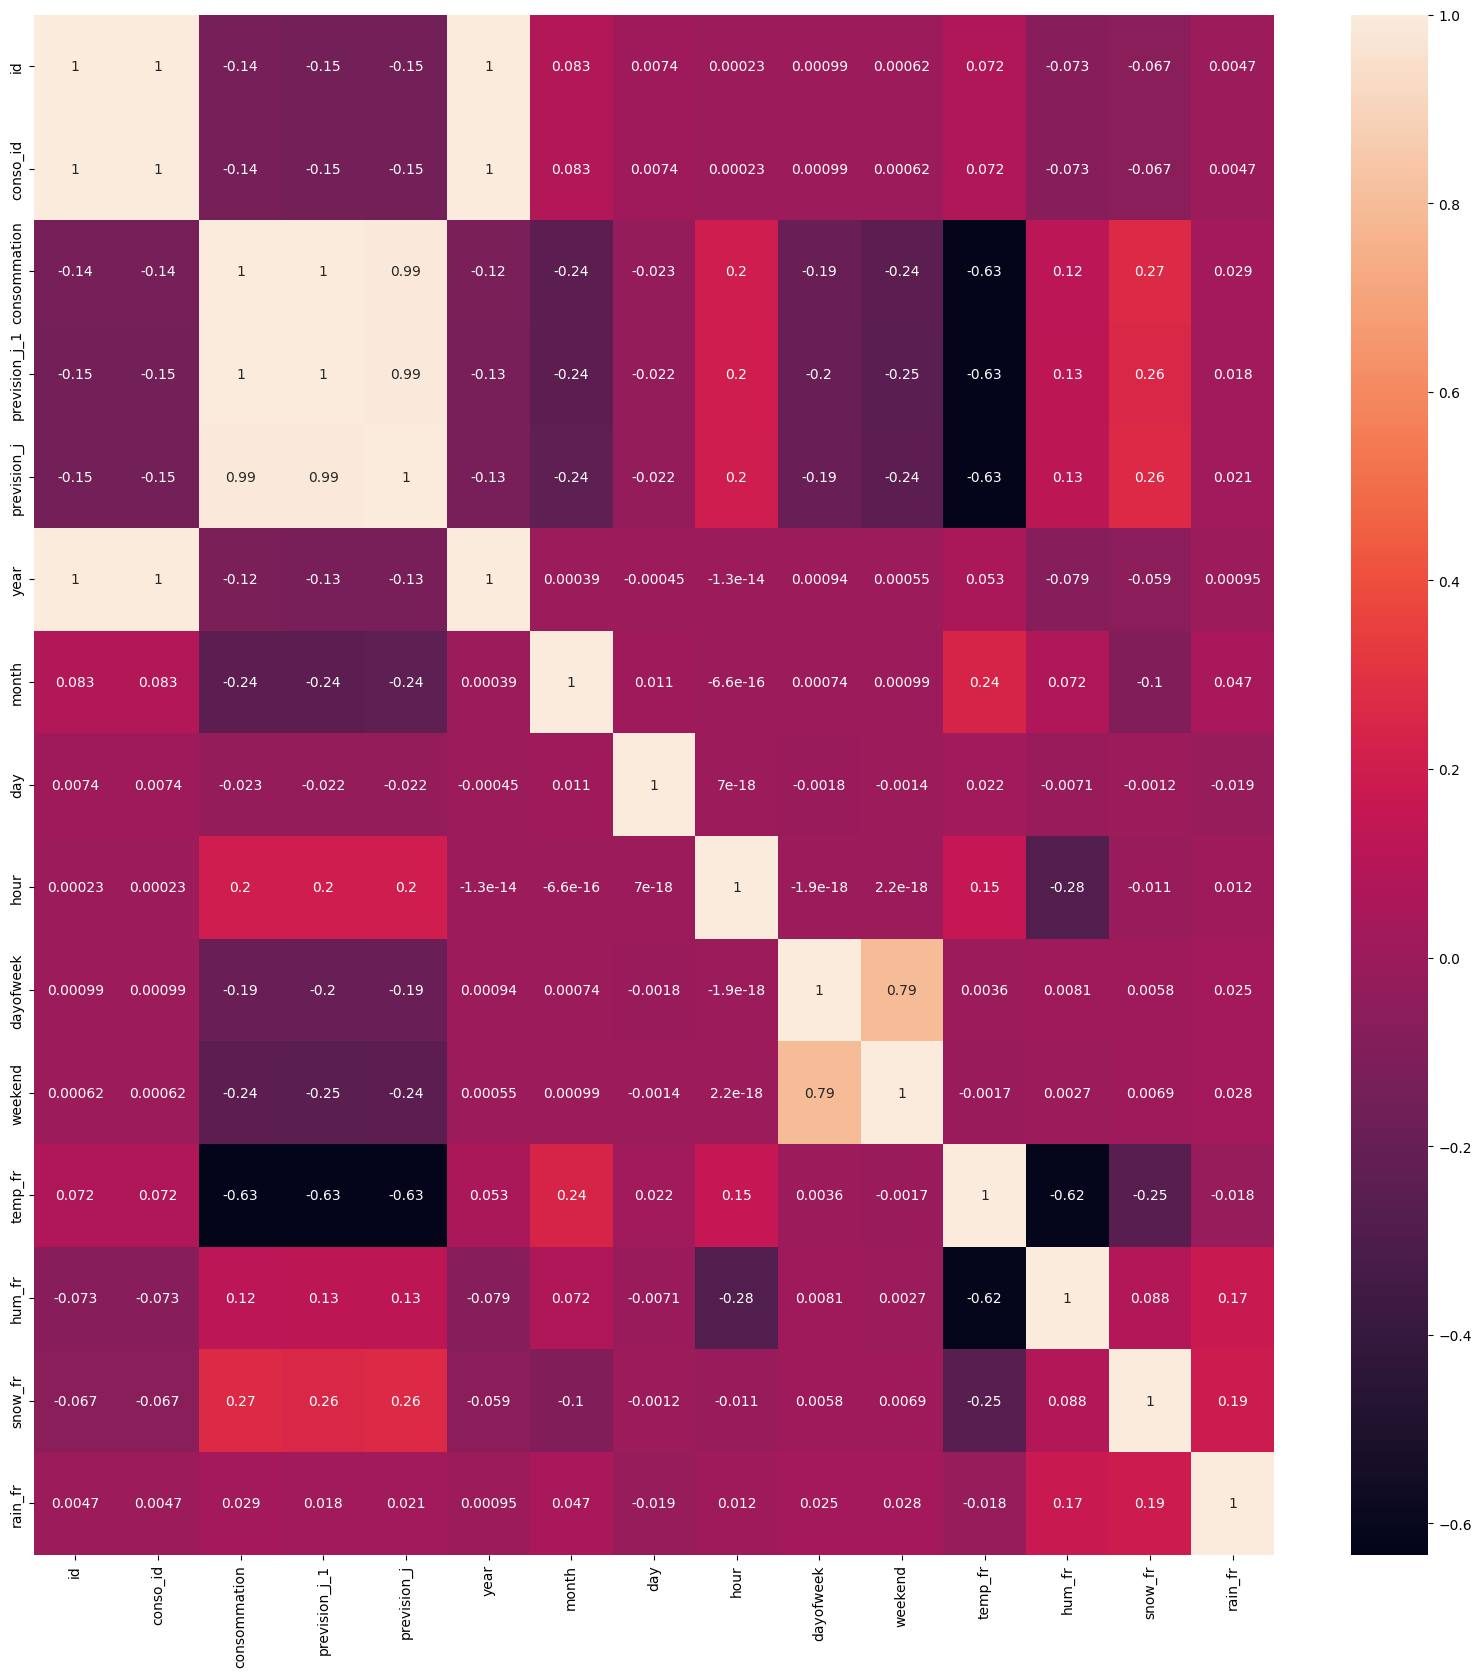

In [89]:
plt.figure(figsize = (20, 20))


corr = df_features.corr(numeric_only= True)

sns.heatmap(data = corr, annot = True)
plt.show()

### Plot target


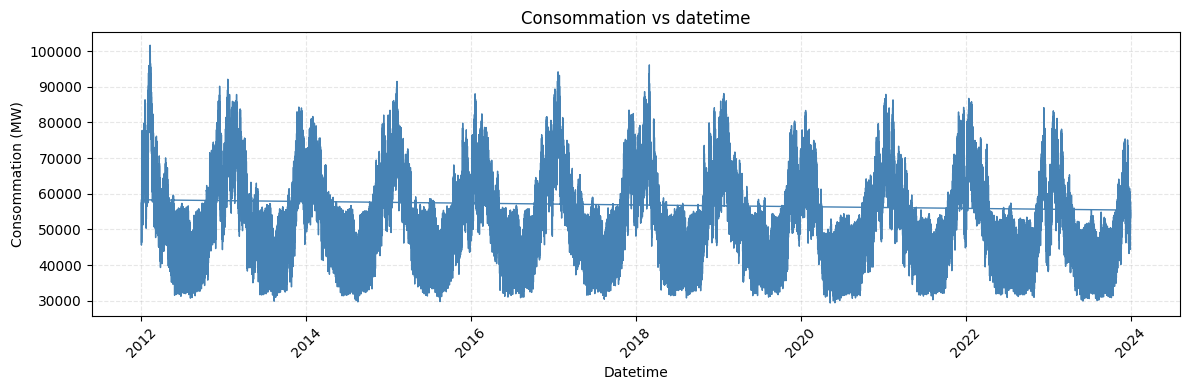

In [90]:
# Visualiser la consommation dans le temps
dt_index = pd.to_datetime({
    "year": df_features["year"],
    "month": df_features["month"],
    "day": df_features["day"],
    "hour": df_features["hour"],
}, errors="coerce")
plot_feature_over_time(dt_index, df_features["consommation"], 
                       "Consommation vs datetime", "Consommation (MW)", color="steelblue")

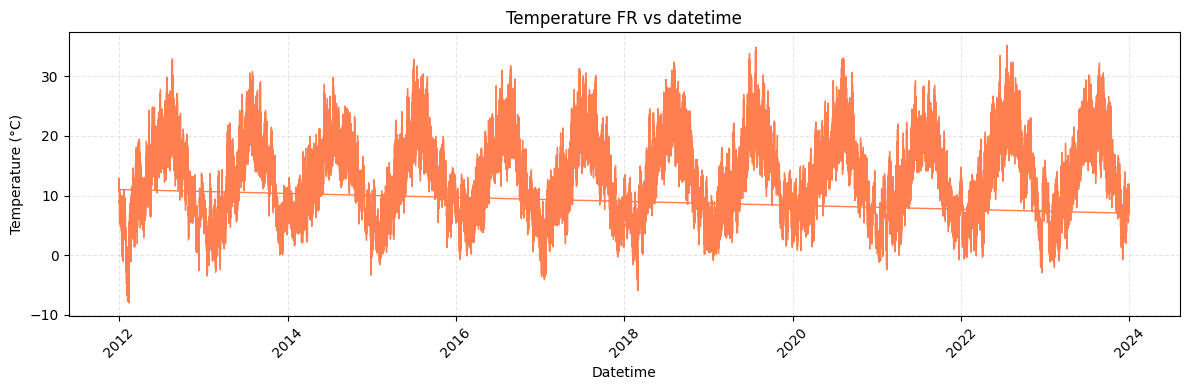

In [91]:
plot_feature_over_time(dt_index, df_features["temp_fr"], 
                       "Temperature FR vs datetime", "Temperature (°C)", color="coral")

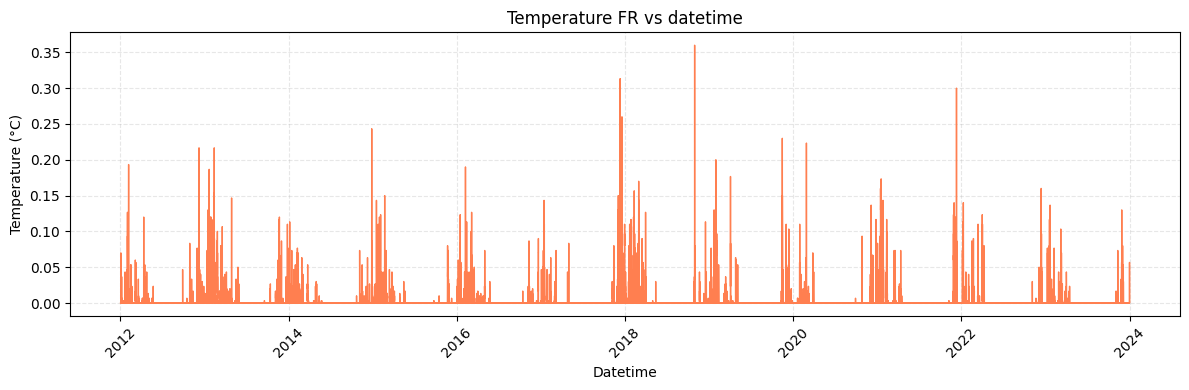

In [92]:
plot_feature_over_time(dt_index, df_features["snow_fr"], 
                       "Temperature FR vs datetime", "Temperature (°C)", color="coral")

In [93]:
df_features.columns

Index(['id', 'conso_id', 'consommation', 'prevision_j_1', 'prevision_j',
       'year', 'month', 'day', 'hour', 'dayofweek', 'weekend', 'datetime',
       'temp_fr', 'hum_fr', 'snow_fr', 'rain_fr'],
      dtype='object')

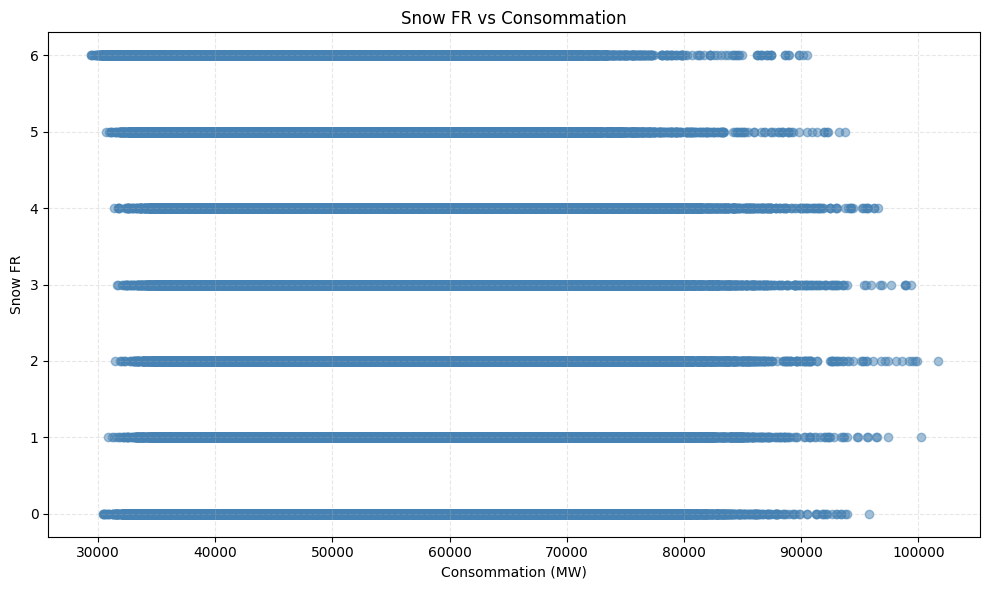

In [94]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_features["consommation"], df_features["dayofweek"], alpha=0.5, color="steelblue")
ax.set_ylabel("Snow FR")
ax.set_xlabel("Consommation (MW)")
ax.set_title("Snow FR vs Consommation")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

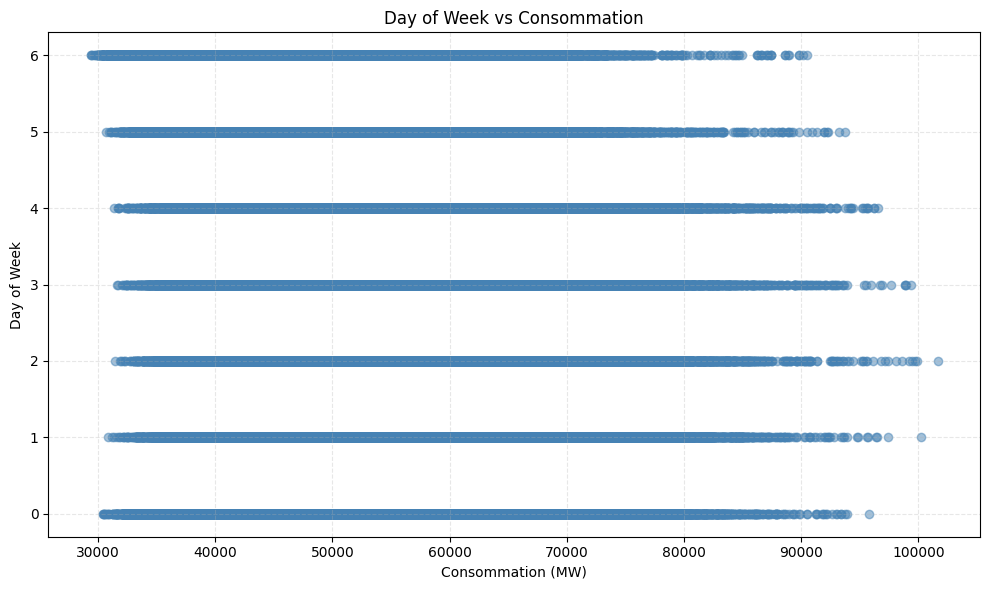

In [95]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_features["consommation"], df_features["dayofweek"], alpha=0.5, color="steelblue")
ax.set_ylabel("Day of Week")
ax.set_xlabel("Consommation (MW)")
ax.set_title("Day of Week vs Consommation")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

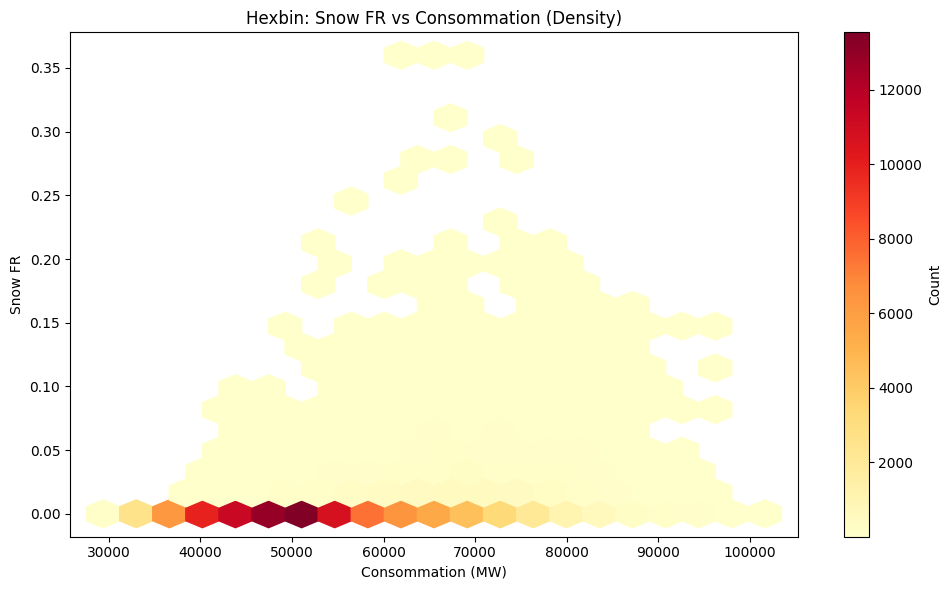

In [96]:
# Hexbin plot - Density visualization
fig, ax = plt.subplots(figsize=(10, 6))
hexbin = ax.hexbin(df_features["consommation"],df_features["snow_fr"], gridsize=20, cmap='YlOrRd', mincnt=1)
ax.set_ylabel("Snow FR")
ax.set_xlabel("Consommation (MW)")
ax.set_title("Hexbin: Snow FR vs Consommation (Density)")
plt.colorbar(hexbin, ax=ax, label='Count')
plt.tight_layout()

In [97]:
# Créer une copie pour ne pas modifier le dataframe original
df_corr = df_features.copy()

# Calculer les corrélations avec la cible
correlations = df_corr.corr()['consommation'].abs().sort_values(ascending=False)

# Retirer la corrélation de la cible avec elle-même et prendre les 8 premières
top_8_features = correlations.drop('consommation').head(8)

print("Les 8 features les plus corrélées avec 'consommation' sont :")
print(top_8_features)

Les 8 features les plus corrélées avec 'consommation' sont :
prevision_j_1    0.995437
prevision_j      0.990726
temp_fr          0.633083
snow_fr          0.265305
month            0.240677
weekend          0.239449
hour             0.198013
dayofweek        0.187008
Name: consommation, dtype: float64


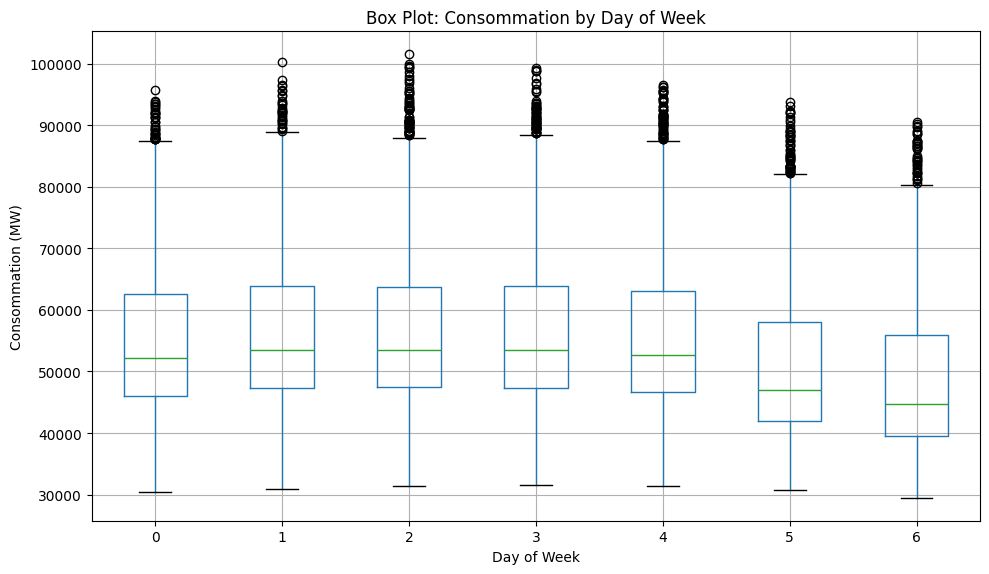

In [98]:
# Box plot - Distribution by day of week
fig, ax = plt.subplots(figsize=(10, 6))
df_features.boxplot(column='consommation', by='dayofweek', ax=ax)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Consommation (MW)")
ax.set_title("Box Plot: Consommation by Day of Week")
plt.suptitle('')
plt.tight_layout()

/tmp/ipykernel_215090/587066354.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_features, x='dayofweek', y='consommation', ax=ax, palette='Set2')


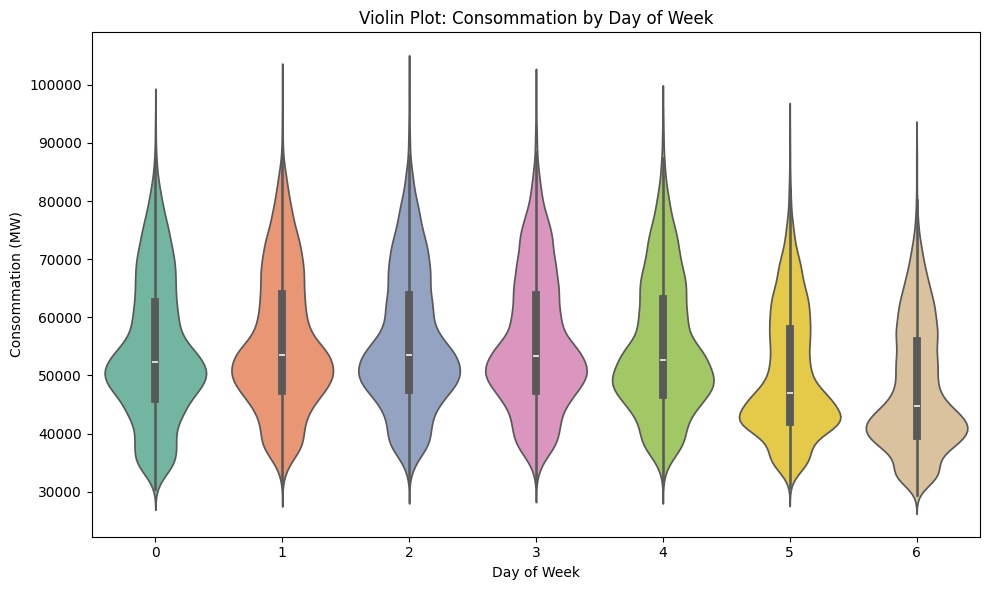

In [99]:
# Violin plot - Distribution comparison
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df_features, x='dayofweek', y='consommation', ax=ax, palette='Set2')
ax.set_xlabel("Day of Week")
ax.set_ylabel("Consommation (MW)")
ax.set_title("Violin Plot: Consommation by Day of Week")
plt.tight_layout()

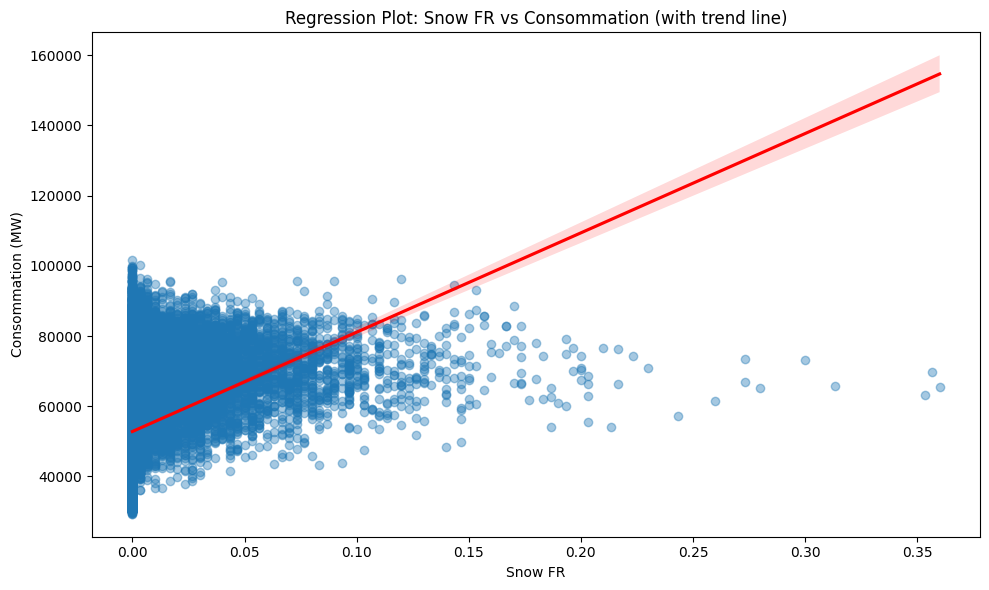

In [100]:
# Regression plot with KDE
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x='snow_fr', y='consommation', data=df_features, ax=ax, scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'})
ax.set_xlabel("Snow FR")
ax.set_ylabel("Consommation (MW)")
ax.set_title("Regression Plot: Snow FR vs Consommation (with trend line)")
plt.tight_layout()

### Matrice de corrélation avec la variable cible

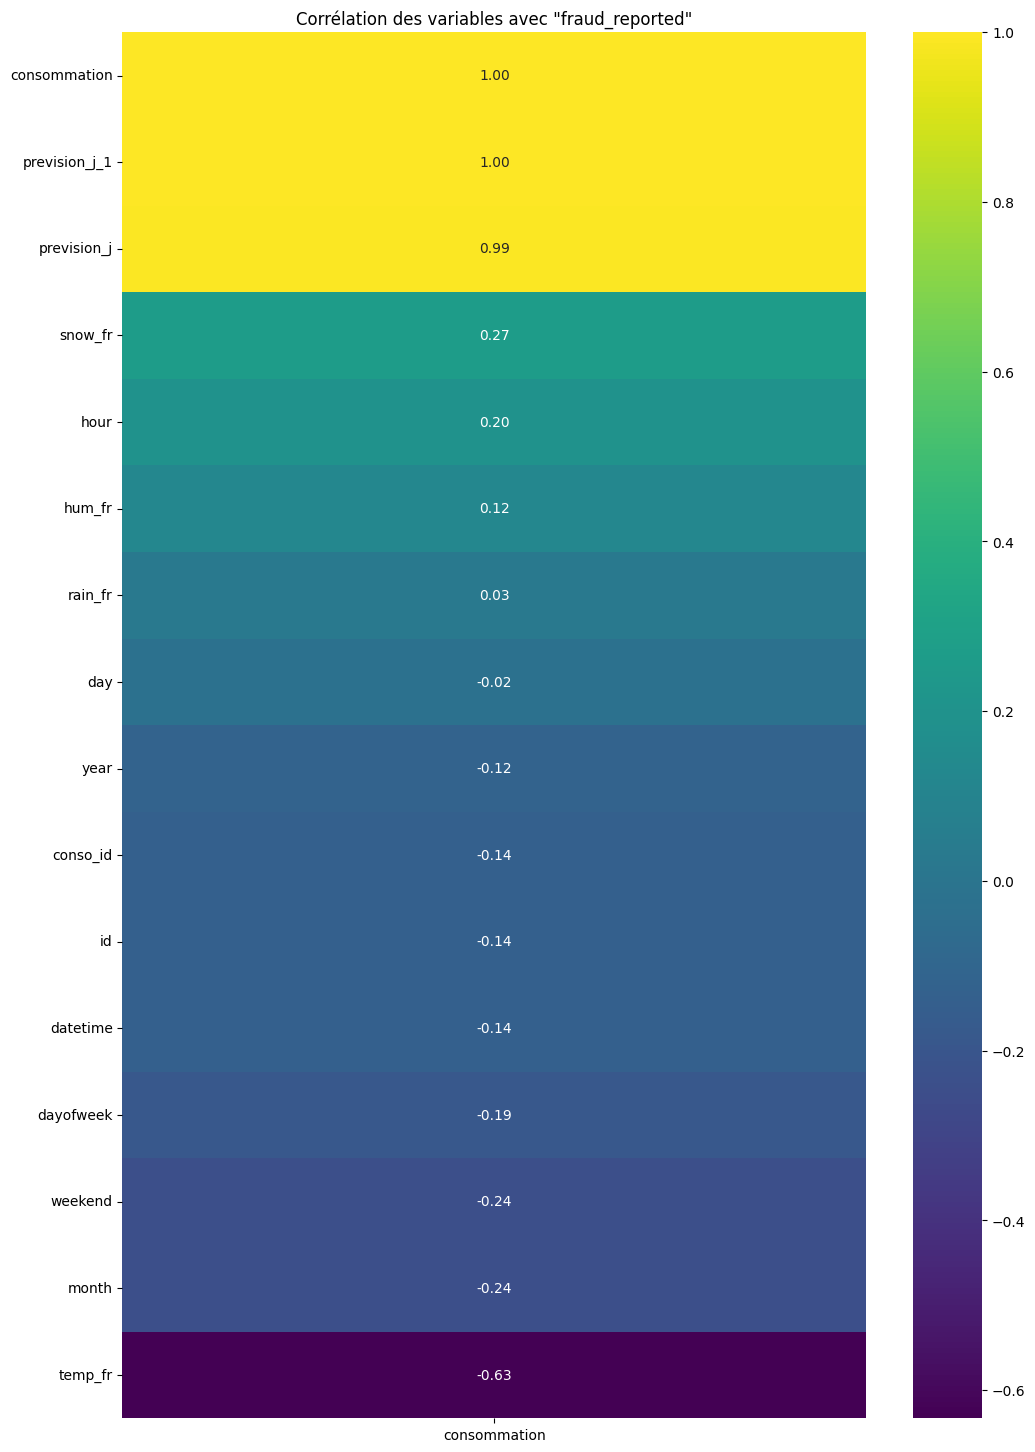

Top 10 des corrélations des features avec la cible (calculées sur le jeu d'entraînement) :
               consommation
consommation       1.000000
prevision_j_1      0.995437
prevision_j        0.990726
snow_fr            0.265305
hour               0.198013
hum_fr             0.124260
rain_fr            0.029045
day               -0.022651
year              -0.120725
conso_id          -0.140160

/!\ ALERTE FUITE DE DONNÉES POTENTIELLE /!\
Les variables suivantes sont très fortement corrélées à la cible et doivent être examinées :
               consommation
consommation       1.000000
prevision_j_1      0.995437
prevision_j        0.990726
snow_fr                 NaN
hour                    NaN
hum_fr                  NaN
rain_fr                 NaN
day                     NaN
year                    NaN
conso_id                NaN
id                      NaN
datetime                NaN
dayofweek               NaN
weekend                 NaN
month                   NaN
temp_fr        

In [101]:


# Calculer la corrélation de toutes les variables avec la variable cible
corr_target = df_corr.corr()[['consommation']].sort_values(by='consommation', ascending=False)

# Visualisation
plt.figure(figsize=(12, 18))
sns.heatmap(corr_target, annot=True, cmap='viridis', fmt=".2f")
plt.title('Corrélation des variables avec "fraud_reported"')
plt.show()



# Afficher les corrélations les plus élevées
print("Top 10 des corrélations des features avec la cible (calculées sur le jeu d'entraînement) :")
print(corr_target.head(10))

# Test : Identifier les fuites potentielles (corrélation > 0.9)
potential_leaks = corr_target[corr_target > 0.9]

if not potential_leaks.empty and 'fraud_reported' in potential_leaks:
    potential_leaks = potential_leaks.drop('fraud_reported') # Exclure la cible elle-même

if not potential_leaks.empty:
    print("\n/!\\ ALERTE FUITE DE DONNÉES POTENTIELLE /!\\")
    print("Les variables suivantes sont très fortement corrélées à la cible et doivent être examinées :")
    print(potential_leaks)
else:
    print("\n-> Aucune fuite de données évidente détectée via l'analyse de corrélation.")

In [102]:
df_features

,id,conso_id,consommation,prevision_j_1,prevision_j,year,month,day,hour,dayofweek,weekend,datetime,temp_fr,hum_fr,snow_fr,rain_fr
0,321,321,68115.5,66712.5,68000.0,2012,1,14,8,5,1,2012-01-14 08:00:00,1.205357,91.289133,0.0,0.0
1,322,322,70709.0,69187.5,70475.0,2012,1,14,9,5,1,2012-01-14 09:00:00,1.926786,89.010151,0.0,0.0
2,323,323,72015.5,70662.5,71262.5,2012,1,14,10,5,1,2012-01-14 10:00:00,3.164881,83.669252,0.0,0.0
3,324,324,71348.5,70862.5,70500.0,2012,1,14,11,5,1,2012-01-14 11:00:00,4.226786,77.082078,0.0,0.0
4,325,325,71292.0,71887.5,70675.0,2012,1,14,12,5,1,2012-01-14 12:00:00,4.936310,72.773125,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105187,316,316,62402.0,61250.0,61312.5,2012,1,14,3,5,1,2012-01-14 03:00:00,1.576786,90.526904,0.0,0.0
105188,317,317,60588.0,59300.0,59687.5,2012,1,14,4,5,1,2012-01-14 04:00:00,1.372024,90.543861,0.0,0.0
105189,318,318,60507.0,59175.0,60025.0,2012,1,14,5,5,1,2012-01-14 05:00:00,1.174405,90.422957,0.0,0.0
105190,319,319,62284.0,60887.5,62062.5,2012,1,14,6,5,1,2012-01-14 06:00:00,0.926786,90.210057,0.0,0.0


In [103]:
df_features.replace('?', np.nan, inplace=True)

# Drop variables too correlated with the target (data leakage)
df_features.drop(["prevision_j_1","prevision_j"], axis=1, inplace=True)

# Drop variables with low correlation with the target
df_features.drop(["day","year","id"], axis=1, inplace=True)

# Now separate features and target
X = df_features.drop('consommation', axis=1)
y = df_features['consommation']

In [104]:
X

,conso_id,month,hour,dayofweek,weekend,datetime,temp_fr,hum_fr,snow_fr,rain_fr
0,321,1,8,5,1,2012-01-14 08:00:00,1.205357,91.289133,0.0,0.0
1,322,1,9,5,1,2012-01-14 09:00:00,1.926786,89.010151,0.0,0.0
2,323,1,10,5,1,2012-01-14 10:00:00,3.164881,83.669252,0.0,0.0
3,324,1,11,5,1,2012-01-14 11:00:00,4.226786,77.082078,0.0,0.0
4,325,1,12,5,1,2012-01-14 12:00:00,4.936310,72.773125,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
105187,316,1,3,5,1,2012-01-14 03:00:00,1.576786,90.526904,0.0,0.0
105188,317,1,4,5,1,2012-01-14 04:00:00,1.372024,90.543861,0.0,0.0
105189,318,1,5,5,1,2012-01-14 05:00:00,1.174405,90.422957,0.0,0.0
105190,319,1,6,5,1,2012-01-14 06:00:00,0.926786,90.210057,0.0,0.0


In [105]:
y

0         68115.5
1         70709.0
2         72015.5
3         71348.5
4         71292.0
           ...   
105187    62402.0
105188    60588.0
105189    60507.0
105190    62284.0
105191    64885.5
Name: consommation, Length: 105192, dtype: float64

In [106]:


# Séparer les données brutes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

X_train_num = X_train.drop("datetime", axis=1)
X_test_num = X_test.drop("datetime", axis=1)

# 2. Définir les pipelines de transformation
numeric_features = X_train.select_dtypes(include=np.number).columns
print(" ------------- numeric_features ------------- ")
print(numeric_features.tolist())

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ],
    remainder='drop'
)


# 3. Pré-traiter X_train et identifier les 8 meilleures features
# On ajuste ET transforme X_train
X_train_processed = preprocessor.fit_transform(X_train_num)
X_test_processed = preprocessor.transform(X_test_num)

 ------------- numeric_features ------------- 
['conso_id', 'month', 'hour', 'dayofweek', 'weekend', 'temp_fr', 'hum_fr', 'snow_fr', 'rain_fr']


,conso_id,month,hour,dayofweek,weekend,datetime,temp_fr,hum_fr,snow_fr,rain_fr
8385,8706,12,17,4,0,2012-12-28 17:00:00,10.014881,82.615453,0.000000,0.000000
17146,17467,12,18,5,1,2013-12-28 18:00:00,7.100595,85.803770,0.076667,0.500000
51549,51870,12,5,4,0,2017-12-01 05:00:00,0.850500,86.025779,0.066667,0.109524
42547,42868,11,3,0,0,2016-11-21 03:00:00,11.691071,85.411617,0.000000,0.300000
71214,71535,2,14,4,0,2020-02-28 14:00:00,10.579071,64.188854,0.000000,0.052381
...,...,...,...,...,...,...,...,...,...,...
54886,55207,4,6,3,0,2018-04-19 06:00:00,12.807643,75.477867,0.000000,0.000000
76820,77141,10,4,0,0,2020-10-19 04:00:00,6.752881,90.203077,0.000000,0.000000
103694,104015,11,22,6,1,2023-11-12 22:00:00,12.198119,89.225760,0.000000,0.433333
860,1181,2,4,6,1,2012-02-19 04:00:00,3.652976,87.118696,0.000000,0.128571


In [107]:
corr_target

,consommation
consommation,1.000000
prevision_j_1,0.995437
prevision_j,0.990726
snow_fr,0.265305
hour,0.198013
hum_fr,0.124260
rain_fr,0.029045
day,-0.022651
year,-0.120725
conso_id,-0.140160


In [108]:
df_features

,conso_id,consommation,month,hour,dayofweek,weekend,datetime,temp_fr,hum_fr,snow_fr,rain_fr
0,321,68115.5,1,8,5,1,2012-01-14 08:00:00,1.205357,91.289133,0.0,0.0
1,322,70709.0,1,9,5,1,2012-01-14 09:00:00,1.926786,89.010151,0.0,0.0
2,323,72015.5,1,10,5,1,2012-01-14 10:00:00,3.164881,83.669252,0.0,0.0
3,324,71348.5,1,11,5,1,2012-01-14 11:00:00,4.226786,77.082078,0.0,0.0
4,325,71292.0,1,12,5,1,2012-01-14 12:00:00,4.936310,72.773125,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
105187,316,62402.0,1,3,5,1,2012-01-14 03:00:00,1.576786,90.526904,0.0,0.0
105188,317,60588.0,1,4,5,1,2012-01-14 04:00:00,1.372024,90.543861,0.0,0.0
105189,318,60507.0,1,5,5,1,2012-01-14 05:00:00,1.174405,90.422957,0.0,0.0
105190,319,62284.0,1,6,5,1,2012-01-14 06:00:00,0.926786,90.210057,0.0,0.0


In [109]:
numeric_features

Index(['conso_id', 'month', 'hour', 'dayofweek', 'weekend', 'temp_fr',
       'hum_fr', 'snow_fr', 'rain_fr'],
      dtype='object')

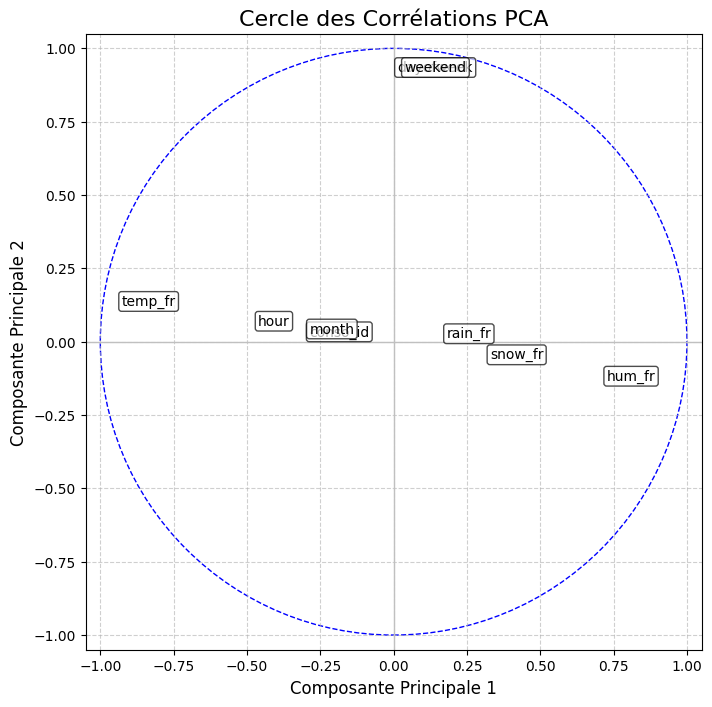

In [110]:
# Using X_train for the analysis
#features_for_pca = df_featurenumeric_features[['snow_fr','hour','temp_fr','month','weekend','dayofweek']]

features_for_pca = df_features[numeric_features].copy()

data_scaled_df = pd.DataFrame(features_for_pca, columns=features_for_pca.columns)

# Performing PCA with prince
pca = prince.PCA(
    n_components=len(features_for_pca.columns),
    rescale_with_mean=True,
    rescale_with_std=True,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=SEED
)

pca = pca.fit(data_scaled_df)

# Calling the plot function
f_plot_circle(pca, features_for_pca)

## Entrainement et Test

In [111]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

def train_models(X, y):
    models = {
        "LinearRegression": LinearRegression(),
        "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
        "KNN": KNeighborsRegressor(n_neighbors=7),
    }

    trained = {}
    for name, model in models.items():
        model.fit(X, y)
        trained[name] = model
    return trained


In [112]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    eps = 1e-9
    return np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100


def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    return {
        "R2": r2_score(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAPE (%)": mape(y_test, y_pred),
    }


In [115]:
models = train_models(X_train_processed, y_train)

best_name, best_model, best_r2 = None, None, -999
for name, model in models.items():
    metrics = evaluate_model(model, X_test_processed, y_test)
    print(f"Modèle : {name}")
    for k, v in metrics.items():
        print(f"{k} : {v:.4f}")

    if metrics["R2"] > best_r2:
        best_r2 = metrics["R2"]
        best_name, best_model = name, model

Modèle : LinearRegression
R2 : 0.6407
RMSE : 7139.7833
MAPE (%) : 11.2811
Modèle : RandomForest
R2 : 0.9679
RMSE : 2133.2087
MAPE (%) : 2.6057
Modèle : KNN
R2 : 0.9297
RMSE : 3158.9802
MAPE (%) : 4.3372


### 📐 Interprétation Métriques

- **R2** : Pourcentage de Performance 
- **RMSE** : Plus gros écart entre la valeur prédite et la valeur de référence
- **MAPE** : Pourcentage du plus gros écart entre la valeur prédite et la valeur de référence